# Quickstart

In [1]:
from immunowave import models, spatial
import numpy as np
import matplotlib.pyplot as plt

## Define a model

In [2]:
model = models.FHNB(
    α=1.0,
    θ=0.1,
    η=1.0,
    ρ=0.0,
    ε=0.0,
    ξ=0.0,
    λ=0.0,
    μ=0.0,
)
model

FHNB(α=1.0, θ=0.1, η=1.0, ρ=0.0, ε=0.0, ξ=0.0, λ=0.0, μ=0.0)

## Initialize fields

Spatial discretization

In [3]:
lb = -50.0
ub = 50.0
n = 100

In [4]:
A = spatial.GridFn(lb, ub, np.zeros(n))
R = spatial.GridFn(lb, ub, np.zeros(n))
B = spatial.GridFn(lb, ub, np.zeros(n))

B.values[n // 2] = 1.0 * (n - 1) / (ub - lb)

B.integral()

Array(1., dtype=float64)

## Define time domain

In [5]:
t0 = 0.0
t1 = 100.0
t = np.linspace(t0, t1, 10)

## Solve

In [6]:
state0 = np.array([A, R, B])

In [7]:
model(0.0, state0, ())

(GridFn(
   ndim=1,
   lb=f64[1],
   ub=f64[1],
   shape=i64[1],
   spacing=f64[1],
   values=f64[100]
 ),
 GridFn(
   ndim=1,
   lb=f64[1],
   ub=f64[1],
   shape=i64[1],
   spacing=f64[1],
   values=f64[100](numpy)
 ),
 GridFn(
   ndim=1,
   lb=f64[1],
   ub=f64[1],
   shape=i64[1],
   spacing=f64[1],
   values=f64[100]
 ))

In [8]:
solution = model.solve(state0, t=t, dt0=None)

TypeError: Dtype object is not a valid JAX array type. Only arrays of numeric types are supported by JAX.

## Plot

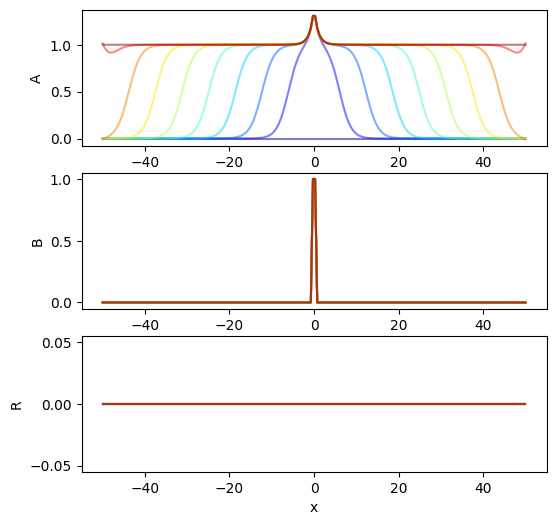

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6, 2 * 3))
n = 20
import matplotlib.pylab as pl

colors = pl.cm.jet(np.linspace(0, 1, len(t)))
for i in range(len(t)):
    ti = t[i]
    statei = {name: values[i] for name, values in solution.ys.items()}
    iwm.plot(model, statei, axes, alpha=0.5, color=colors[i])
plt.show()